In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load FD001 Training data
train_df = pd.read_csv('train_FD001.csv')

# Drop columns with zero variance (sensors that don't move provide no info)
# Example: setting3, s1, s5, s10, s16, s18, s19 are often constant in FD001
train_df = train_df.loc[:, (train_df != train_df.iloc[0]).any()]


# Define your window (W)
window = 30 



In [10]:
# 1. Calculate the maximum cycle for each unit (the point of failure)
max_cycle = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_nr', 'max_cycle']

# 2. Merge back to the main dataframe
train_df = train_df.merge(max_cycle, on='unit_nr', how='left')

# 3. Calculate RUL: (Final Cycle - Current Cycle)
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

# 4. Create the Binary Label: 1 if failure is within 30 cycles, 0 otherwise
window = 30
train_df['label'] = train_df['RUL'].apply(lambda x: 1 if x <= window else 0)

# 5. Drop the helper 'max_cycle' column
train_df.drop('max_cycle', axis=1, inplace=True)

print("Check the new columns:")
print(train_df[['unit_nr', 'time_cycles', 'RUL', 'label']].head())

# Create the binary label: 1 if RUL <= 30, else 0
train_df['label'] = train_df['RUL'].apply(lambda x: 1 if x <= window else 0)

Check the new columns:
   unit_nr  time_cycles  RUL  label
0        1            1  191      0
1        1            2  190      0
2        1            3  189      0
3        1            4  188      0
4        1            5  187      0


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Define features (all sensor and setting columns)
features = ['setting1', 'setting2', 'T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']
X = train_df[features]
y = train_df['label']

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3507
           1       0.89      0.87      0.88       620

    accuracy                           0.96      4127
   macro avg       0.93      0.92      0.93      4127
weighted avg       0.96      0.96      0.96      4127



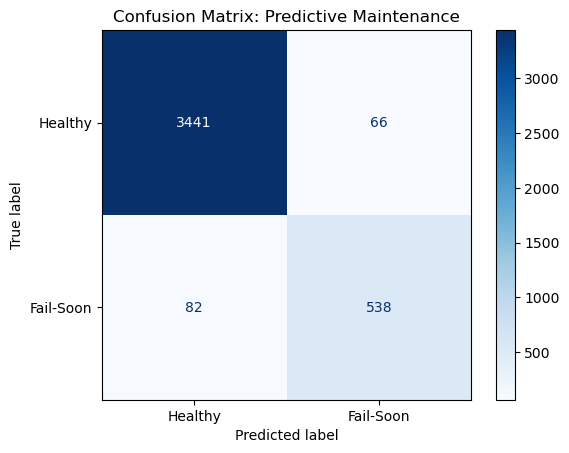

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = rf.predict(X_val)

# Generate the report
print("--- Classification Report ---")
print(classification_report(y_val, y_pred))

# Plot the Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Fail-Soon'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predictive Maintenance')
plt.show()

C:\Users\muzammil shakeel\AppData\Local\Temp\ipykernel_13588\2539198161.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


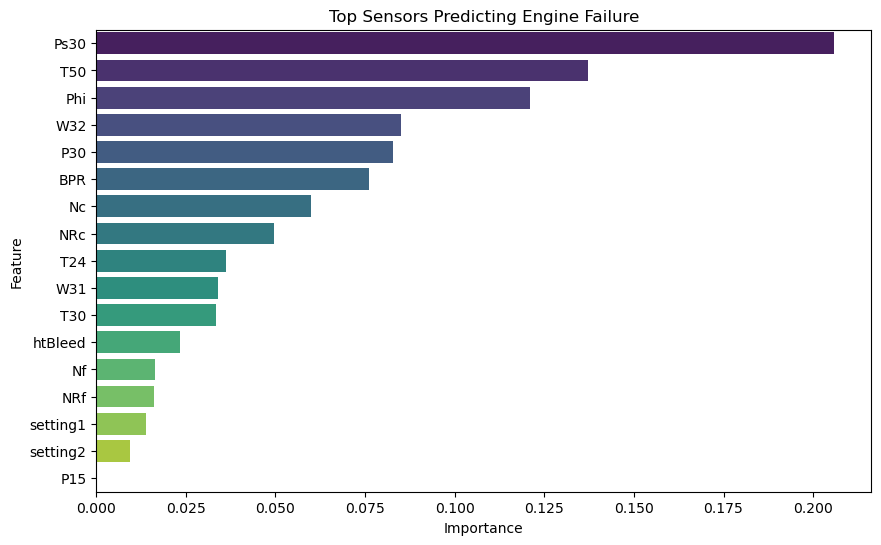

In [13]:
import matplotlib.pyplot as plt

# Get importance from the model
importances = rf.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Sensors Predicting Engine Failure')
plt.show()

In [14]:
# We'll pick the top 5 sensors from your graph to avoid 'feature bloat'
top_sensors = ['Ps30', 'T50', 'Phi', 'W32', 'P30']

# Calculate rolling mean for a 10-cycle window per engine unit
for sensor in top_sensors:
    train_df[sensor + '_rolling_mean'] = train_df.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window=10).mean())

# Rolling windows create 'NaN' for the first 9 rows of every engine. We must drop them.
train_df_rolled = train_df.dropna()

print(f"New shape after rolling features: {train_df_rolled.shape}")

New shape after rolling features: (19731, 26)


In [15]:
# Updated feature list including the new rolling columns
new_features = features + [s + '_rolling_mean' for s in top_sensors]

X_rolled = train_df_rolled[new_features]
y_rolled = train_df_rolled['label']

# Split again
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_rolled, y_rolled, test_size=0.2, random_state=42, stratify=y_rolled)

# Retrain
rf_rolled = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rolled.fit(X_train_r, y_train_r)

# Evaluate
y_pred_r = rf_rolled.predict(X_val_r)
print("--- Updated Classification Report (With Rolling Features) ---")
print(classification_report(y_val_r, y_pred_r))

--- Updated Classification Report (With Rolling Features) ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3327
           1       0.90      0.85      0.87       620

    accuracy                           0.96      3947
   macro avg       0.94      0.91      0.93      3947
weighted avg       0.96      0.96      0.96      3947



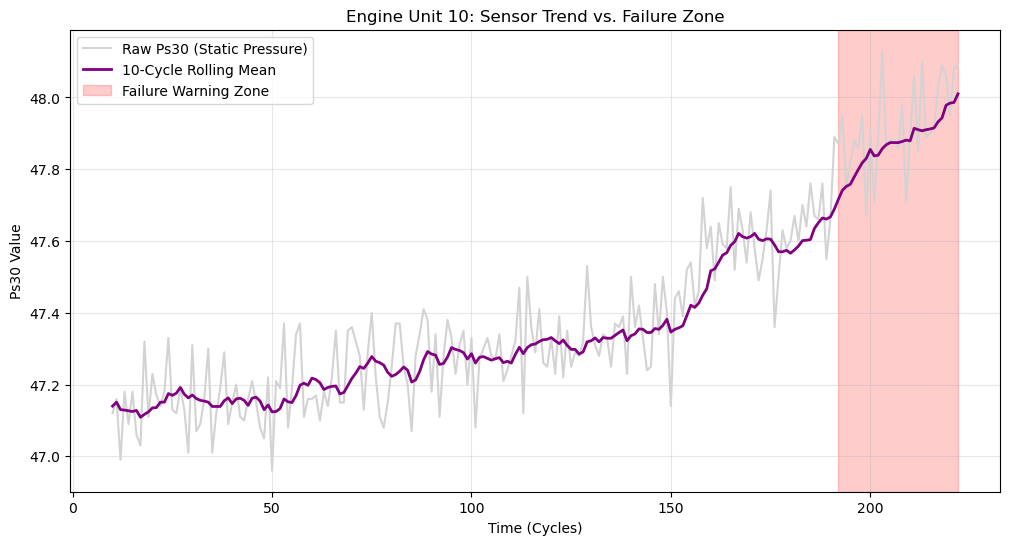

In [16]:
# Choose a specific engine unit to visualize (e.g., Unit 10)
unit_id = 10
unit_data = train_df_rolled[train_df_rolled['unit_nr'] == unit_id]

plt.figure(figsize=(12, 6))

# Plot Raw Data
plt.plot(unit_data['time_cycles'], unit_data['Ps30'], color='lightgray', label='Raw Ps30 (Static Pressure)')

# Plot Rolling Mean
plt.plot(unit_data['time_cycles'], unit_data['Ps30_rolling_mean'], color='purple', linewidth=2, label='10-Cycle Rolling Mean')

# Highlight the Failure Zone
plt.axvspan(unit_data['time_cycles'].max() - 30, unit_data['time_cycles'].max(), color='red', alpha=0.2, label='Failure Warning Zone')

plt.title(f'Engine Unit {unit_id}: Sensor Trend vs. Failure Zone')
plt.xlabel('Time (Cycles)')
plt.ylabel('Ps30 Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
import joblib

# Create a dictionary to hold the model and the metadata
model_artifacts = {
    'model': rf_rolled,
    'features': new_features,
    'window_size': 30,
    'top_sensors': top_sensors
}

# Save to a file
joblib.dump(model_artifacts, 'predictive_maintenance_model.pkl')

print("Model saved as 'predictive_maintenance_model.pkl'!")

Model saved as 'predictive_maintenance_model.pkl'!


In [19]:
# --- SIMULATING DEPLOYMENT ---
# Load the model back
loaded_artifacts = joblib.load('predictive_maintenance_model.pkl')
my_model = loaded_artifacts['model']
my_features = loaded_artifacts['features']

# Take one sample row from the validation set
sample_data = X_val_r.iloc[[0]] 

# Make a prediction
prediction = my_model.predict(sample_data)
probability = my_model.predict_proba(sample_data)[0][1]

print(f"Prediction: {'MAINTENANCE REQUIRED' if prediction[0] == 1 else 'SYSTEM HEALTHY'}")
print(f"Failure Probability: {probability * 100:.2f}%")

Prediction: SYSTEM HEALTHY
Failure Probability: 0.00%


In [26]:
# 1. Reload and Clean
test_df = pd.read_csv('test_FD001.csv')
true_rul = pd.read_csv('RUL_FD001.csv', header=None, names=['RUL_actual'])

# Force RUL_actual to numeric and reset index
true_rul['RUL_actual'] = pd.to_numeric(true_rul['RUL_actual'], errors='coerce')
true_rul = true_rul.dropna().reset_index(drop=True)
true_rul['unit_nr'] = true_rul.index + 1  # Standard 1-100

# 2. Add Rolling Features (Top 5 sensors)
for sensor in top_sensors:
    test_df[sensor + '_rolling_mean'] = test_df.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window=10).mean())

# 3. Get the LAST row per unit
test_last = test_df.groupby('unit_nr').last().reset_index()

# --- DEBUG PRINT ---
print(f"Units in Test File: {test_last['unit_nr'].unique()[:5]}")
print(f"Units in RUL File: {true_rul['unit_nr'].unique()[:5]}")

# 4. Merge using 'unit_nr' and ensure types match
test_last['unit_nr'] = test_last['unit_nr'].astype(int)
true_rul['unit_nr'] = true_rul['unit_nr'].astype(int)

test_combined = pd.merge(test_last, true_rul, on='unit_nr', how='inner')

# 5. Create labels
test_combined['label_actual'] = test_combined['RUL_actual'].apply(lambda x: 1 if x <= 30 else 0)

print(f"\nFinal Test Data Rows: {len(test_combined)}")
if len(test_combined) > 0:
    print(test_combined[['unit_nr', 'RUL_actual', 'label_actual']].head())

Units in Test File: [1 2 3 4 5]
Units in RUL File: []

Final Test Data Rows: 0


In [29]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the Test Data (assuming it has headers now)
test_df = pd.read_csv('test_FD001.csv')

# 2. Load the RUL Data and fix the column name/index
# In your file, the RUL values are in the 'unit_nr' column due to the header shift
rul_data = pd.read_csv('RUL_FD001.csv')
true_rul = pd.DataFrame()
true_rul['RUL_actual'] = rul_data['unit_nr']
true_rul['unit_nr'] = range(1, len(true_rul) + 1)

# 3. Apply the same Feature Engineering (Rolling Means)
top_sensors = ['Ps30', 'T50', 'Phi', 'W32', 'P30']
for sensor in top_sensors:
    test_df[sensor + '_rolling_mean'] = test_df.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window=10).mean())

# 4. Get the last record for each engine unit in the test set
test_last = test_df.groupby('unit_nr').last().reset_index()

# 5. Merge with ground truth RUL
test_combined = pd.merge(test_last, true_rul, on='unit_nr')

# 6. Create the True Binary Labels (1 if failure within 30 cycles, else 0)
test_combined['label_actual'] = test_combined['RUL_actual'].apply(lambda x: 1 if x <= 30 else 0)

# 7. Drop rows with NaN (from the rolling window)
test_combined.dropna(inplace=True)

print(f"Successfully matched {len(test_combined)} engines for evaluation.")

Successfully matched 100 engines for evaluation.



--- FINAL EVALUATION ON UNSEEN TEST DATA ---
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        75
           1       0.94      0.68      0.79        25

    accuracy                           0.91       100
   macro avg       0.92      0.83      0.87       100
weighted avg       0.91      0.91      0.90       100



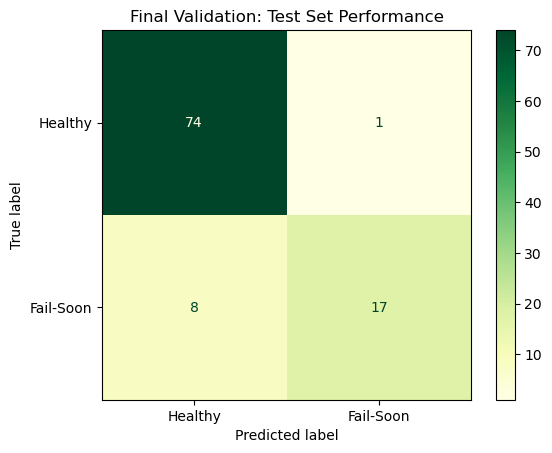

In [30]:
# Use the same feature list as training
# features = ['setting1', 'setting2', 'T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']
# new_features = features + [s + '_rolling_mean' for s in top_sensors]

X_test_final = test_combined[new_features]
y_test_actual = test_combined['label_actual']

# Predict
y_test_pred = rf_rolled.predict(X_test_final)

# Display the Final Result
print("\n--- FINAL EVALUATION ON UNSEEN TEST DATA ---")
print(classification_report(y_test_actual, y_test_pred))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test_actual, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Fail-Soon'])
disp.plot(cmap='YlGn')
plt.title('Final Validation: Test Set Performance')
plt.show()